In [2]:
import pandas as pd

df = pd.read_csv('/content/bookcabin_reviews.csv')
display(df.head())

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,fb60aaa9-0dfe-431a-ae8b-b8c8c0c3a937,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"applikasi terlalu banyak bug, untuk apa adanya...",1,0,6.5.3,2026-04-30 16:02:00,NaN,NaN,6.5.3
1,b4990d01-39f0-43ec-a231-eef344873098,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Respon Customer Care sangat mengecewakan,1,0,6.5.1,2026-04-30 05:47:15,NaN,NaN,6.5.1
2,76f6ed6a-1f02-4282-855f-916a3c99a0ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,scam. penipu. beli tiket sudah brasil malah ga...,1,0,NaN,2026-04-29 04:52:42,NaN,NaN,NaN
3,371dd53e-fa03-4842-9d9b-509e3c7c8f55,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sy sudah mengajukan refund, tapi kenapa masih ...",1,0,6.5.2,2026-04-29 01:37:42,NaN,NaN,6.5.2
4,0625c812-0f16-435b-a11d-72e95ab9ae2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,5,0,6.5.2,2026-04-28 12:03:09,NaN,NaN,6.5.2


### Data Inspection

In [3]:
# Tampilkan informasi dasar tentang DataFrame (tipe data, non-null count, memory usage)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4170 entries, 0 to 4169
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              4170 non-null   object
 1   userName              4170 non-null   object
 2   userImage             4170 non-null   object
 3   content               4170 non-null   object
 4   score                 4170 non-null   int64 
 5   thumbsUpCount         4170 non-null   int64 
 6   reviewCreatedVersion  3681 non-null   object
 7   at                    4170 non-null   object
 8   replyContent          1 non-null      object
 9   repliedAt             1 non-null      object
 10  appVersion            3681 non-null   object
dtypes: int64(2), object(9)
memory usage: 358.5+ KB


In [4]:
# Cek nilai yang hilang
print("\nJumlah nilai yang hilang di setiap kolom:")
display(df.isnull().sum())


Jumlah nilai yang hilang di setiap kolom:


,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,489
at,0
replyContent,4169
repliedAt,4169


In [5]:
# Tampilkan statistik deskriptif untuk kolom numerik
print("\nStatistik Deskriptif untuk Kolom Numerik:")
display(df.describe())


Statistik Deskriptif untuk Kolom Numerik:


,score,thumbsUpCount
count,4170.000000,4170.000000
mean,4.167866,1.478417
std,1.534171,6.306563
min,1.000000,0.000000
25%,4.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,1.000000
max,5.000000,180.000000


In [6]:
# Konversi kolom 'at' menjadi tipe data datetime
df['at'] = pd.to_datetime(df['at'], errors='coerce')

# Verifikasi perubahan tipe data
print("\nTipe data setelah konversi kolom 'at':")
df.info()


Tipe data setelah konversi kolom 'at':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4170 entries, 0 to 4169
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4170 non-null   object        
 1   userName              4170 non-null   object        
 2   userImage             4170 non-null   object        
 3   content               4170 non-null   object        
 4   score                 4170 non-null   int64         
 5   thumbsUpCount         4170 non-null   int64         
 6   reviewCreatedVersion  3681 non-null   object        
 7   at                    4170 non-null   datetime64[ns]
 8   replyContent          1 non-null      object        
 9   repliedAt             1 non-null      object        
 10  appVersion            3681 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 358.5+ KB


### Analisis Konten Ulasan: Word Cloud

### Analisis Tren Ulasan dari Waktu ke Waktu

In [10]:
# Ekstrak tanggal dari kolom 'at'
df['date'] = df['at'].dt.date

# Hitung jumlah ulasan per hari
reviews_per_day = df.groupby('date').size().reset_index(name='review_count')

# Hitung rata-rata skor per hari
average_score_per_day = df.groupby('date')['score'].mean().reset_index(name='average_score')

# Gabungkan kedua DataFrame
trends_df = pd.merge(reviews_per_day, average_score_per_day, on='date')

# Konversi kolom 'date' kembali ke datetime untuk plotting
trends_df['date'] = pd.to_datetime(trends_df['date'])

display(trends_df.head())

,date,review_count,average_score
0,2023-09-22,1,5.0
1,2023-10-01,1,5.0
2,2023-10-08,4,5.0
3,2023-10-10,1,5.0
4,2023-10-18,1,5.0


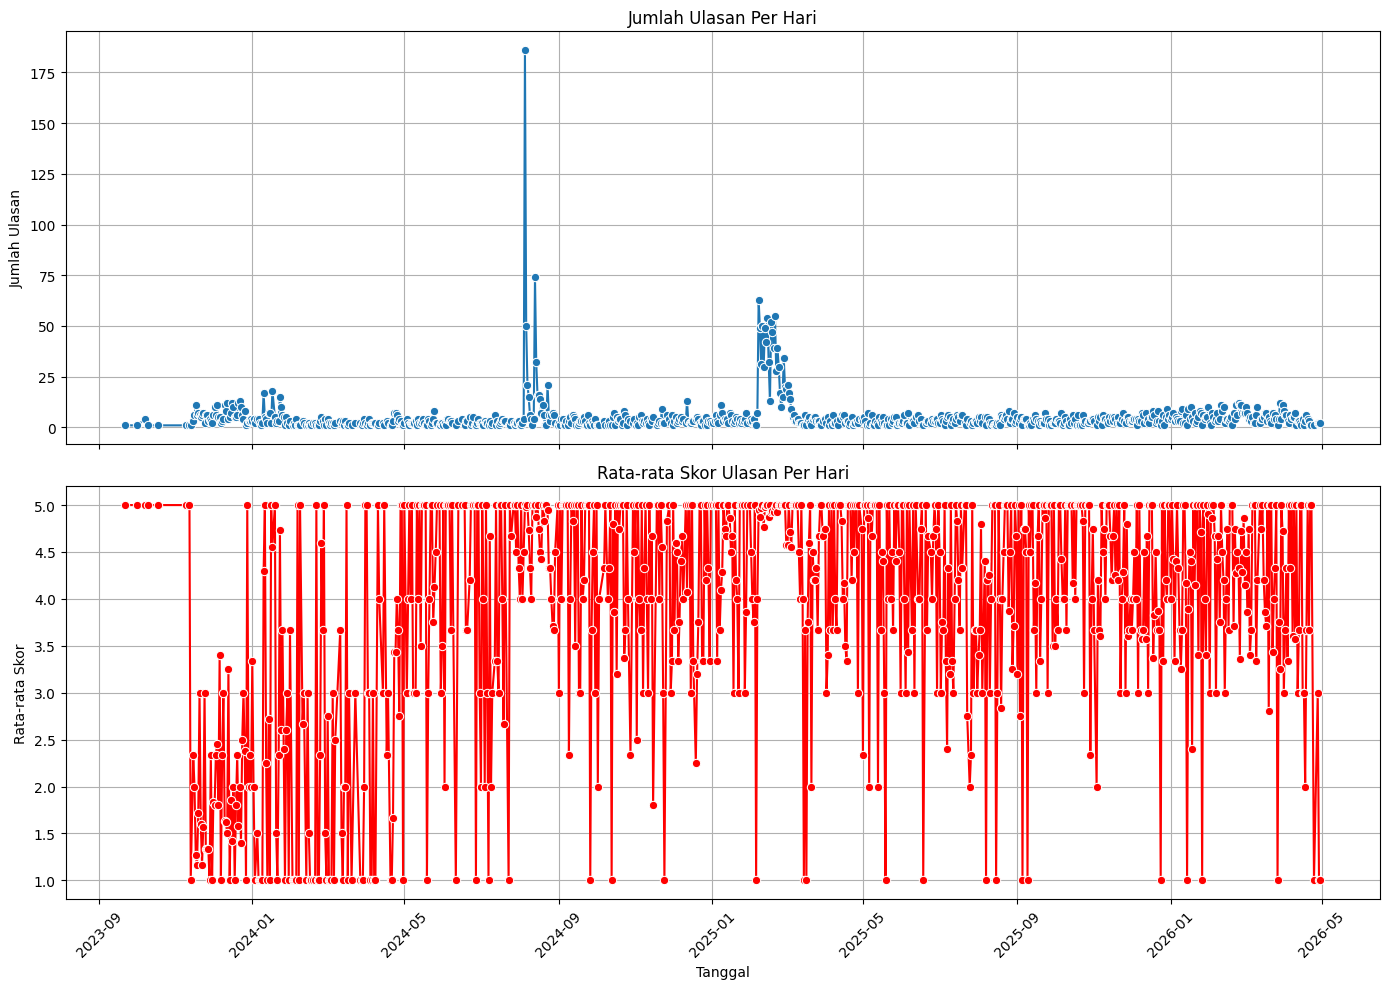

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot jumlah ulasan per hari
sns.lineplot(ax=axes[0], x='date', y='review_count', data=trends_df, marker='o')
axes[0].set_title('Jumlah Ulasan Per Hari')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].grid(True)

# Plot rata-rata skor per hari
sns.lineplot(ax=axes[1], x='date', y='average_score', data=trends_df, marker='o', color='red')
axes[1].set_title('Rata-rata Skor Ulasan Per Hari')
axes[1].set_ylabel('Rata-rata Skor')
axes[1].set_xlabel('Tanggal')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

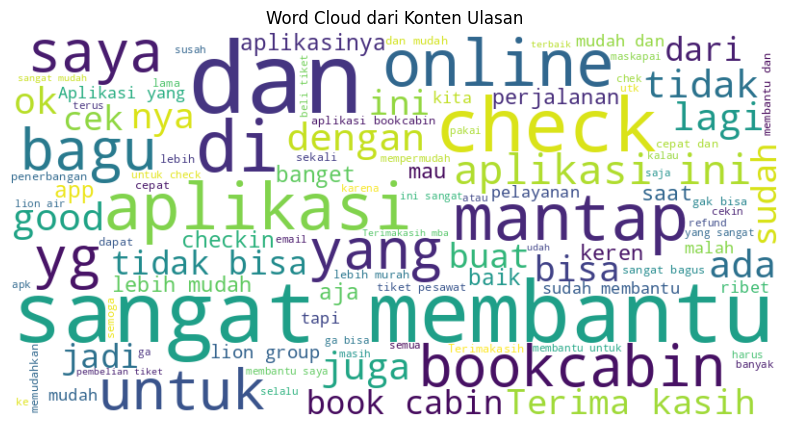

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua teks ulasan menjadi satu string
text = " ".join(review for review in df.content)

# Buat objek WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      min_font_size=10).generate(text)

# Tampilkan Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Konten Ulasan')
plt.show()

### Analisis Word Cloud Ulasan Positif dan Negatif

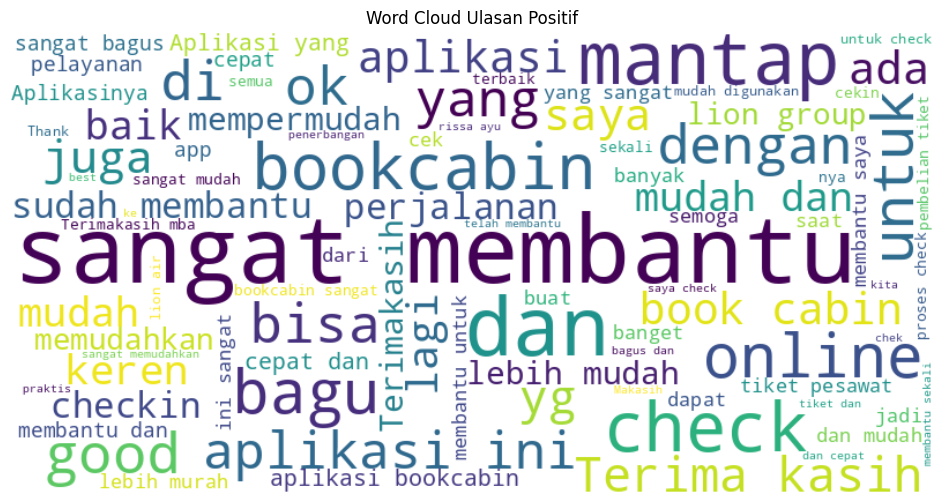

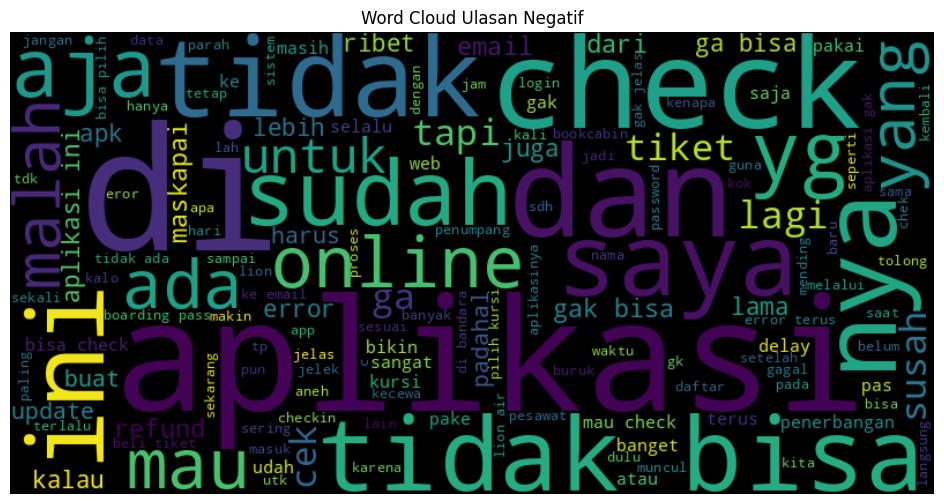

In [13]:
# Filter ulasan positif (skor 4 atau 5)
positive_reviews = df[df['score'].isin([4, 5])]['content']
text_positive = " ".join(review for review in positive_reviews)

# Filter ulasan negatif (skor 1 atau 2)
negative_reviews = df[df['score'].isin([1, 2])]['content']
text_negative = " ".join(review for review in negative_reviews)

# Buat Word Cloud untuk ulasan positif
wordcloud_positive = WordCloud(width=800, height=400,
                               background_color='white',
                               min_font_size=10).generate(text_positive)

# Buat Word Cloud untuk ulasan negatif
wordcloud_negative = WordCloud(width=800, height=400,
                               background_color='black',
                               colormap='viridis',
                               min_font_size=10).generate(text_negative)

# Tampilkan Word Cloud ulasan positif
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Positif')
plt.show()

# Tampilkan Word Cloud ulasan negatif
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Negatif')
plt.show()

### Analisis Distribusi Skor Ulasan

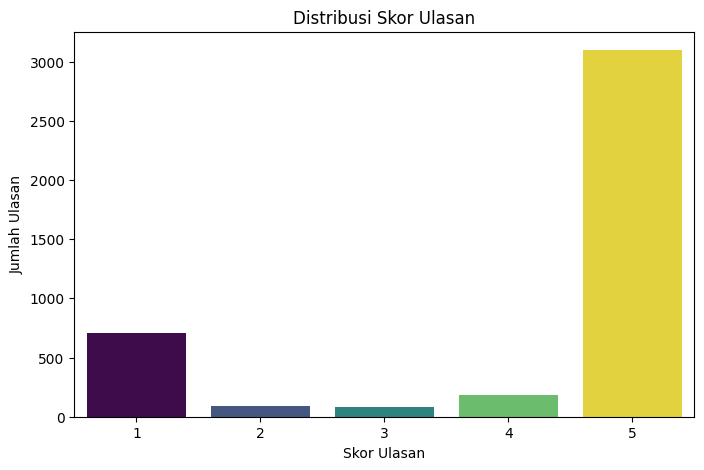

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', hue='score', palette='viridis', legend=False)
plt.title('Distribusi Skor Ulasan')
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah Ulasan')
plt.show()